**Import libraries**

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt

**Load file as dataframe**

In [13]:
folder_path = "../data/emg_data_original"
file_names = [f"grip_{i}.txt" for i in range(1, 13)]  # grip_1.txt to grip_12.txt

# Initialize an empty list to store DataFrames
all_data = []

# Loop through each file and load its data
for grip_num, file_name in enumerate(file_names, start=1):
    file_path = os.path.join(folder_path, file_name)
    
    data = []
    gesture_repetition = 0

    # Read the file line by line
    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()

            # If "#" appears, increase repetition count
            if line.startswith("#"):
                gesture_repetition += 1
                continue

            # Split by ";" and convert to float
            values = line.split(";")
            values = [float(v) for v in values if v]
            
            # Append to list with repetition index and grip pattern label
            if len(values) >= 1:
                data.append([gesture_repetition, grip_num, values[4]])

    # Convert to DataFrame
    columns = ["gesture_repetition", "grip_pattern", "ch5_env"]
    df = pd.DataFrame(data, columns=columns)
    df.dropna(inplace=True)  # Remove NaNs if any

    # Append to master list
    all_data.append(df)

# Merge all DataFrames into one
merged_df = pd.concat(all_data, ignore_index=True)

# Save merged dataset to CSV
merged_df.to_csv("../data/emg_data_processed/merged_emg_data_ch5.csv", index=False)

print("Merged dataset saved as 'merged_emg_data_ch5.csv'.")
print(merged_df.head())  # Show first few rows

Merged dataset saved as 'merged_emg_data_ch5.csv'.
   gesture_repetition  grip_pattern   ch5_env
0                   1             1  0.089569
1                   1             1  0.089722
2                   1             1  0.089645
3                   1             1  0.089645
4                   1             1  0.091171


**Sliding windows**

In [14]:
df = pd.read_csv("../data/emg_data_processed/merged_emg_data_ch5.csv")

WINDOW_SIZE = 200  # 200 time steps per window
STEP_SIZE = 50  # Overlapping step size

windowed_data = []
windowed_labels = []

# Loop through each gesture repetition
for repetition in df["gesture_repetition"].unique():
    subset = df[df["gesture_repetition"] == repetition]  # Filter one repetition

    # Apply sliding window segmentation
    for start in range(0, len(subset) - WINDOW_SIZE, STEP_SIZE):
        window = subset.iloc[start : start + WINDOW_SIZE]["ch5_env"]
        windowed_data.append(window.values.flatten())  # Flatten to 1D
        windowed_labels.append(subset["grip_pattern"].iloc[start])  # Use first row's label

# Convert to DataFrame
num_features = WINDOW_SIZE # 1 EMG channel per time step
columns = [f"feature_{i}" for i in range(num_features)] + ["grip_pattern"]
windowed_df = pd.DataFrame(np.column_stack((windowed_data, windowed_labels)), columns=columns)

# Save processed dataset
windowed_df.to_csv("../data/emg_data_processed/sliding_windows_emg_ch5.csv", index=False)

print(windowed_df.head())  # Check the first few rows

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.089569   0.089722   0.089645   0.089645   0.091171   0.091324   
1   0.092850   0.093079   0.093079   0.092697   0.093155   0.092773   
2   0.098114   0.097580   0.096970   0.097122   0.097427   0.096283   
3   0.091705   0.093231   0.093002   0.092392   0.092545   0.092468   
4   0.100250   0.100250   0.099869   0.099945   0.099030   0.098801   

   feature_6  feature_7  feature_8  feature_9  ...  feature_191  feature_192  \
0   0.091934   0.091629   0.091248   0.091858  ...     0.103683     0.103683   
1   0.092468   0.092697   0.093002   0.091705  ...     0.116959     0.117188   
2   0.096512   0.095825   0.095520   0.096207  ...     0.098114     0.097656   
3   0.093308   0.095520   0.100403   0.103989  ...     0.094223     0.093460   
4   0.098572   0.098267   0.097961   0.097580  ...     0.091705     0.091782   

   feature_193  feature_194  feature_195  feature_196  feature_197  \
0     0.103607     0.1

**Load and preprocess data for CNN**

In [15]:
df = pd.read_csv("../data/emg_data_processed/sliding_windows_emg_ch5.csv")

# Separate features and labels
X = df.drop(columns=["grip_pattern"]).values
y = df["grip_pattern"].values

# Split data: 70% train, 10% tune, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_tune, y_train, y_tune = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp)

# Normalize after splitting to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN: (samples, time_steps, channels)
time_steps = 200  # Each window has 200 time steps
num_channels = 1  # 1 EMG signal per time step
X_train = X_train.reshape((-1, time_steps, num_channels))
X_tune = X_tune.reshape((-1, time_steps, num_channels))
X_test = X_test.reshape((-1, time_steps, num_channels))

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (67924, 200, 1)
Testing Data Shape: (19407, 200, 1)


**One hot encoding for gesture labels**

In [16]:
y_train = np.array(y_train) - 1
y_test = np.array(y_test) - 1

# 12 grip patterns
num_classes = len(np.unique(y_train))

# Integer to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(y_train[:5])  # Print first 5 labels in one-hot format

[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


**Build CNN**

In [17]:
# Build function for tuning

def build_model(hp):
    model = Sequential([
        Input(shape=(time_steps, num_channels)),
        Conv1D(filters=hp.Int('filters', min_value=32, max_value=128, step=16), 
               kernel_size=hp.Int('kernel_size', min_value=3, max_value=7, step=1), 
               activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=hp.Int('filters', min_value=16, max_value=64, step=8), 
               kernel_size=hp.Int('kernel_size', min_value=1, max_value=5, step=1), 
               activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(hp.Int('units', min_value=64, max_value=256, step=32), activation='relu'),
        Dropout(hp.Float('dropout', min_value=0.4, max_value=0.8, step=0.1)),
        Dense(num_classes, activation='softmax')
    ])
       
    tuned_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.compile(optimizer=Adam(learning_rate=tuned_lr), loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()
    return model

**Initialize and run tuner**

In [18]:
tuner_ch5 = kt.BayesianOptimization(build_model,objective='val_loss',max_trials=5,
                                    directory='../tuner_logs',project_name='ch5_tuning', overwrite=True)
tuner_ch5.search(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Trial 5 Complete [00h 10m 49s]
val_loss: 2.0744097232818604

Best val_loss So Far: 1.9768171310424805
Total elapsed time: 01h 24m 28s


**Get best set of hyperparameters**

In [19]:
best_hps_list = tuner_ch5.get_best_hyperparameters(num_trials=5)

for i, hps in enumerate(best_hps_list):
    print(f"Best Hyperparameters Set {i+1}: {hps.values}")

Best Hyperparameters Set 1: {'filters': 96, 'kernel_size': 5, 'units': 256, 'dropout': 0.8, 'learning_rate': 0.0004683184869738412}
Best Hyperparameters Set 2: {'filters': 80, 'kernel_size': 6, 'units': 160, 'dropout': 0.4, 'learning_rate': 0.0034872532359391194}
Best Hyperparameters Set 3: {'filters': 128, 'kernel_size': 4, 'units': 256, 'dropout': 0.8, 'learning_rate': 0.0006596256080803834}
Best Hyperparameters Set 4: {'filters': 64, 'kernel_size': 4, 'units': 96, 'dropout': 0.5, 'learning_rate': 0.00021914305695327043}
Best Hyperparameters Set 5: {'filters': 32, 'kernel_size': 4, 'units': 64, 'dropout': 0.6000000000000001, 'learning_rate': 0.009291751144278985}


**Train with best set of hyperparameters**

In [20]:
best_hps = tuner_ch5.get_best_hyperparameters(num_trials=1)[0]
model = tuner_ch5.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 196, 96)        │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 98, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 94, 96)         │        46,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 47, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4512)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,155,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,205,164 (4.60 MB)

 Trainable params: 1,205,164 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 134s 51ms/step - accuracy: 0.1358 - loss: 2.4081 - val_accuracy: 0.1825 - val_loss: 2.2577
Epoch 2/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 129s 60ms/step - accuracy: 0.1805 - loss: 2.2844 - val_accuracy: 0.2101 - val_loss: 2.1921
Epoch 3/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 143s 67ms/step - accuracy: 0.1998 - loss: 2.2329 - val_accuracy: 0.2246 - val_loss: 2.1974
Epoch 4/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 140s 65ms/step - accuracy: 0.2162 - loss: 2.1890 - val_accuracy: 0.2566 - val_loss: 2.1164
Epoch 5/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.2248 - loss: 2.1559 - val_accuracy: 0.2562 - val_loss: 2.0741
Epoch 6/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 139s 65ms/step - accuracy: 0.2331 - loss: 2.1349 - val_accuracy: 0.2680 - val_loss: 2.0348
Epoch 7/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 137s 64ms/step - accuracy: 0.2432 - loss: 2.1118 - val_accuracy: 0.2699 - val_loss: 2.0537
Epoch 8/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 126s 59ms/step - accuracy: 

**Accuracy/loss plots**

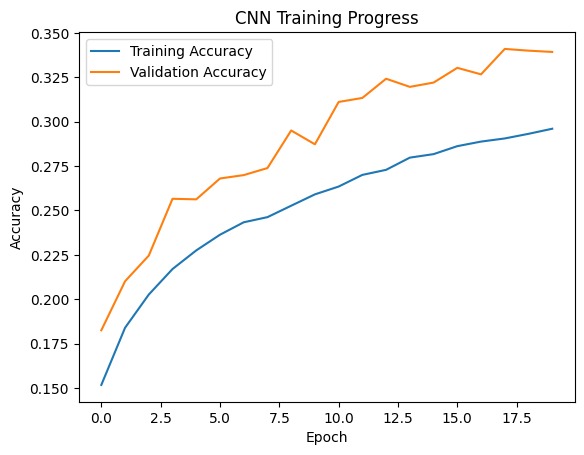

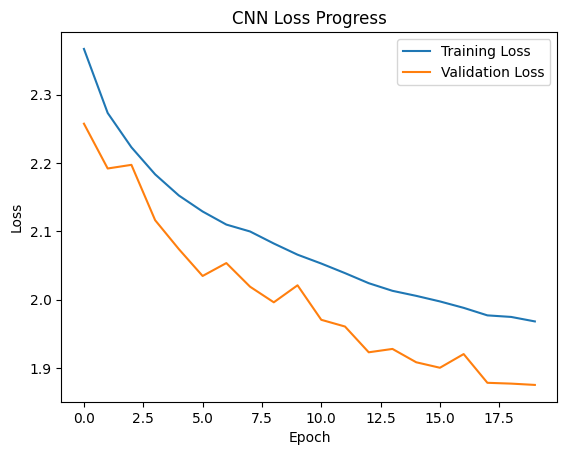

In [21]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Training Progress")
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Loss Progress")
plt.show()

**Save model**

In [22]:
model.save("../models/cnn_tuned_ch5.keras")
print("Model saved successfully!")

Model saved successfully!
